In [18]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize) 

10. This question should be answered using the Carseats data set

In [19]:
Carseats = pd.read_csv('..\..\Datasets\Carseats.csv')
print(Carseats.info())
Carseats[Carseats.select_dtypes(['object']).columns] = Carseats.select_dtypes(['object']).astype('category')
print(Carseats.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Sales        400 non-null    float64 
 1   CompPrice    400 non-null    int64   
 2  

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\olive\AppData\Local\Temp\ipykernel_7620\1450385880.py:1: SyntaxWarning: invalid escape sequence '\.'
  Carseats = pd.read_csv('..\..\Datasets\Carseats.csv')


(a) Fit a multiple regression model to predict Sales using Price,
Urban, and US.

In [20]:
y = Carseats['Sales']
X = MS(['Price', 'Urban', 'US']).fit_transform(Carseats)
modelo = sm.OLS(y, X)
resultados = modelo.fit()
resultados.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.39e-23
Time:                        12:04:55   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban[Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(b) Provide an interpretation of each coefficient in the model. Be
careful—some of the variables in the model are qualitative!

Intercepto 13.0435 - Valor base de venda(Sales) com Urbano = Não e US = Não

Price -0.0545 - Relação negativa, dedução de Y do produto do coeficiente com o valor de Preço

Urban -0.0219 - caso seja urbano, uma dedução desse valor de coeficiente no Y

US 1.2006 - caso seja US, aumentará o coeficiente no valor de Y

In [21]:
summarize(resultados)

,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000


(c) Write out the model in equation form, being careful to handle
the qualitative variables properly.

- ŷ = 13.0435 -0.0545 x Price -0.0219  + 1.2006
- ŷ = 13.0435 -0.0545 x Price -0.0219  
- ŷ = 13.0435 -0.0545 x Price + 1.2006
- ŷ = 13.0435 -0.0545 x Price 

(d) For which of the predictors can you reject the null hypothesis
H0 : βj =0?

In [22]:
df = summarize(resultados)
df[df['P>|t|']<0.05]


,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.0
Price,-0.0545,0.005,-10.389,0.0
US[Yes],1.2006,0.259,4.635,0.0


O p-value maior de 0.05 já pode se considerar a possibilidade H0:βj = 0. 

Outro ponto a se considerar é o T-Value, se também for pequeno, próximo de zero fortalece H0:βj = 0 

Porém como parte do preditor está no intercepto, temos que ter cuidado ao afirmar isso

In [23]:
df[df['P>|t|']>0.05]

,coef,std err,t,P>|t|
Urban[Yes],-0.0219,0.272,-0.081,0.936


(e) On the basis of your response to the previous question, fit a
smaller model that only uses the predictors for which there is
evidence of association with the outcome.

In [24]:
X = MS(['Price', 'US']).fit_transform(Carseats)
modelo2 = sm.OLS(y, X)
resultados2 = modelo2.fit()
resultados2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.66e-24
Time:                        12:04:56   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
from statsmodels.stats.anova import anova_lm

anova_lm(resultados2, resultados)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,397.0,2420.874462,0.0,NaN,NaN,NaN
1,396.0,2420.834671,1.0,0.03979,0.006509,0.935739


(f) How well do the models in (a) and (e) fit the data?

In [26]:
print('Modelo a R2:',resultados.rsquared)
print('Modelo e R2:',resultados2.rsquared)

Modelo a R2: 0.23927539218405547
Modelo e R2: 0.23926288842678567


(g) Using the model from (e), obtain 95 % confidence intervals for
the coefficient(s).

In [27]:
print('Intervalo de confiança:', resultados2.conf_int())
resultados2.params

Intervalo de confiança:                   0          1
intercept  11.79032  14.271265
Price      -0.06476  -0.044195
US[Yes]     0.69152   1.707766


intercept    13.030793
Price        -0.054478
US[Yes]       1.199643
dtype: float64

(h) Is there evidence of outliers or high leverage observations in the
model from (e)?

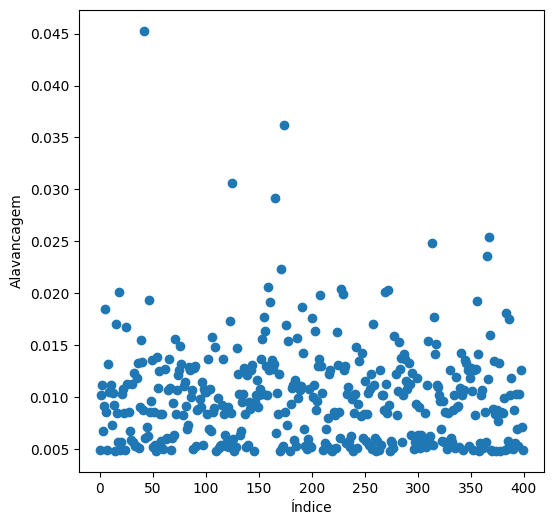

In [28]:
def plot_hat_matrix_diag(res):
    infl = resultados.get_influence()
    ax = subplots(figsize=(6, 6))[1]
    ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
    ax.set_xlabel('Índice')
    ax.set_ylabel('Alavancagem')
    np.argmax(infl.hat_matrix_diag)

plot_hat_matrix_diag(resultados2)

Text(0, 0.5, 'Resíduo Padronizado')

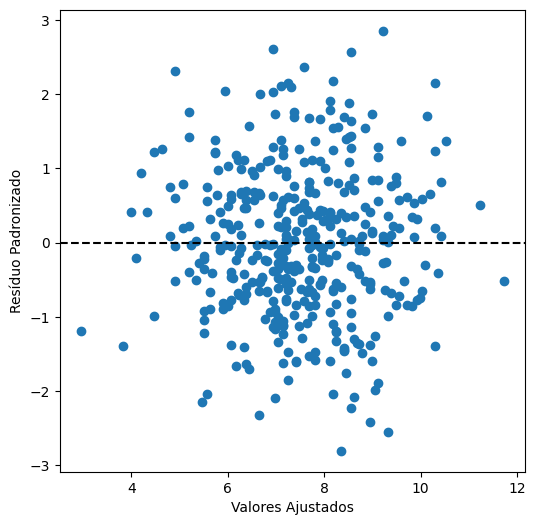

In [29]:
ax = subplots(figsize=(6,6))[1]
ax.scatter(resultados2.fittedvalues, resultados2.resid/np.sqrt(resultados2.scale))
ax.axhline(0, c='k', ls='--')
ax.set_xlabel('Valores Ajustados')
ax.set_ylabel('Resíduo Padronizado')
